# Analysis of voting data 2022 and 2026

**-> run this notebook after running "preperation_primera_vuelta_2022_2026" notebook**

**Data:** first-round presidential results by municipio (`DES_MM`), 2022 and 2026.

**Definitions used**
- *Pacto Histórico (PH)*: Gustavo Petro in 2022, Iván Cepeda Castro in 2026.
- *De La Espriella*: Abelardo De La Espriella (only ran in 2026).
- *Other*: any other candidate who won the municipio (e.g. Rodolfo Hernández or Federico Gutiérrez in 2022, Paloma Valencia in 2026).
- Municipio names are not unique across departments (e.g. the same name can appear in two departments), so a municipio is identified by **department + `DES_MM`**.
- The rows of `CONSULADOS` (votes abroad) and `SAN ANDRES` (island department) are **removed from the data right after loading** (see `EXCLUDE_DEPARTMENTS`), so they are excluded from the entire analysis.

In [ ]:
import pandas as pd
import numpy as np
from IPython.display import display

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

FILE = "voting_data_2022_2026.xlsx"  # change path here    
EXCLUDE_DEPARTMENTS = ['CONSULADOS', 'SAN ANDRES']   # rows removed from the data right after loading (votes abroad + island)
THRESHOLDS = [0.5, 1, 2, 3, 5, 10]            # percent


LOSS_METRIC = 'share'           # this refers to the drop in Pacto Historico's vote share (percentage points) 

PH_2022, PH_2026, ESP = 'Gustavo Petro', 'Iván Cepeda Castro', 'Abelardo De La Espriella'
NON_CANDIDATE = ['Votos En Blanco', 'Votos Nulos', 'Votos No Marcados']

In [ ]:
raw = pd.read_excel("voting_data_2022_2026.xlsx") # change path here
raw[['NUM_VOT_2022', 'NUM_VOT_2026']] = raw[['NUM_VOT_2022', 'NUM_VOT_2026']].fillna(0)
raw = raw[~raw['DES_DD'].isin(EXCLUDE_DEPARTMENTS)].copy()   # remove CONSULADOS and SAN ANDRES
raw['MUNICIPIO'] = raw['DES_MM']
raw.head()

,COD_DDE,DES_DD,COD_MME,DES_MM,DES_CAN,NUM_VOT_2026,NUM_VOT_2022,MUNICIPIO
0,1,ANTIOQUIA,1,MEDELLIN,Abelardo De La Espriella,677108.0,0.0,MEDELLIN
1,1,ANTIOQUIA,1,MEDELLIN,Carlos Eduardo Caicedo Omar,0.0,0.0,MEDELLIN
2,1,ANTIOQUIA,1,MEDELLIN,Claudia López,4963.0,0.0,MEDELLIN
3,1,ANTIOQUIA,1,MEDELLIN,Enrique Gómez Martínez,0.0,2568.0,MEDELLIN
4,1,ANTIOQUIA,1,MEDELLIN,Federico Gutiérrez,0.0,603374.0,MEDELLIN


In [34]:
# data preparation 
KEY = ['DES_DD', 'DES_MM']
cands = raw[~raw['DES_CAN'].isin(NON_CANDIDATE)]

def winner(df, col):
    idx = df.groupby(KEY)[col].idxmax()
    return df.loc[idx].set_index(KEY)['DES_CAN']

def party(name, ph_name):
    if name == ph_name: return 'Pacto Histórico'
    if name == ESP:     return 'De La Espriella'
    return 'Other'

res = pd.DataFrame(index=cands.groupby(KEY).size().index)
res['winner_2022'] = winner(cands, 'NUM_VOT_2022')
res['winner_2026'] = winner(cands, 'NUM_VOT_2026')
res['party_2022'] = res['winner_2022'].map(lambda n: party(n, PH_2022))
res['party_2026'] = res['winner_2026'].map(lambda n: party(n, PH_2026))

res['PH_2022']  = raw[raw.DES_CAN == PH_2022].groupby(KEY)['NUM_VOT_2022'].sum()
res['PH_2026']  = raw[raw.DES_CAN == PH_2026].groupby(KEY)['NUM_VOT_2026'].sum()
res['ESP_2026'] = raw[raw.DES_CAN == ESP].groupby(KEY)['NUM_VOT_2026'].sum()
res['ESP_2022'] = 0
valid = raw[~raw.DES_CAN.isin(['Votos Nulos', 'Votos No Marcados'])].groupby(KEY)[['NUM_VOT_2022', 'NUM_VOT_2026']].sum()
res['valid_2022'], res['valid_2026'] = valid['NUM_VOT_2022'], valid['NUM_VOT_2026']
res = res.fillna(0).reset_index()

res['PH_share_2022'] = 100 * res['PH_2022'] / res['valid_2022']
res['PH_share_2026'] = 100 * res['PH_2026'] / res['valid_2026']
res['ESP_share_2026'] = 100 * res['ESP_2026'] / res['valid_2026']
res['PH_vote_change'] = res['PH_2026'] - res['PH_2022']
res['PH_share_change_pp'] = res['PH_share_2026'] - res['PH_share_2022']
res['PH_rel_change_pct'] = 100 * res['PH_vote_change'] / res['PH_2022'].replace(0, np.nan)

print(f'{len(res)} municipios')
res.head()

1120 municipios


,DES_DD,DES_MM,winner_2022,winner_2026,party_2022,party_2026,PH_2022,PH_2026,ESP_2026,ESP_2022,valid_2022,valid_2026,PH_share_2022,PH_share_2026,ESP_share_2026,PH_vote_change,PH_share_change_pp,PH_rel_change_pct
0,AMAZONAS,EL ENCANTO,Gustavo Petro,Iván Cepeda Castro,Pacto Histórico,Pacto Histórico,168.0,216.0,37.0,0,277.0,270.0,60.649819,80.000000,13.703704,48.0,19.350181,28.571429
1,AMAZONAS,LA CHORRERA,Gustavo Petro,Iván Cepeda Castro,Pacto Histórico,Pacto Histórico,495.0,544.0,25.0,0,604.0,585.0,81.953642,92.991453,4.273504,49.0,11.037811,9.898990
2,AMAZONAS,LA PEDRERA,Gustavo Petro,Iván Cepeda Castro,Pacto Histórico,Pacto Histórico,167.0,327.0,49.0,0,230.0,399.0,72.608696,81.954887,12.280702,160.0,9.346192,95.808383
3,AMAZONAS,LA VICTORIA,Gustavo Petro,Iván Cepeda Castro,Pacto Histórico,Pacto Histórico,21.0,28.0,0.0,0,25.0,29.0,84.000000,96.551724,0.000000,7.0,12.551724,33.333333
4,AMAZONAS,LETICIA,Gustavo Petro,Iván Cepeda Castro,Pacto Histórico,Pacto Histórico,7560.0,10415.0,7327.0,0,17850.0,20654.0,42.352941,50.426068,35.474969,2855.0,8.073126,37.764550


## Task 1 – Sorting municipios 

- How many votes did PH loose?  (comparison of raw vote counts and vote share) 
- How many votes did PH win? (comparison raw vote counts and vote share)
- Municipios where PH won both in 2022 and 2026 



In [35]:
# ---------------------------------------------------------------------------
# Raw vote counts vs. vote share
# ---------------------------------------------------------------------------
n = len(res)
raw_chg   = res['PH_2026'] - res['PH_2022']                 # change in raw PH votes
share_chg = res['PH_share_2026'] - res['PH_share_2022']     # change in PH vote share (pp)

comp = pd.DataFrame({
    'raw vote counts': [(raw_chg < 0).sum(), (raw_chg > 0).sum(), (raw_chg == 0).sum()],
    'vote share':      [(share_chg < 0).sum(), (share_chg > 0).sum(), (share_chg == 0).sum()]},
    index=['PH lost (2026 < 2022)', 'PH gained (2026 > 2022)', 'PH unchanged'])
comp.loc['Total municipios'] = [n, n]
print('In how many municipios did PH lose / gain raw votes vs. vote share?')
display(comp)

print('Comparison of raw votes (rows) vs. vote share of PH:')
display(pd.crosstab(np.where(raw_chg < 0, 'lost raw votes', 'gained/kept raw votes'),
                    np.where(share_chg < 0, 'lost share', 'gained/kept share'), margins=True))

print('Municipios where PH won in both 2022 and 2026:')
both = res[(res['party_2022'] == 'Pacto Histórico') & (res['party_2026'] == 'Pacto Histórico')]
display(pd.DataFrame({
    'n_municipios': [len(both), (both.PH_2026 < both.PH_2022).sum(), (both.PH_2026 >= both.PH_2022).sum(),
                     (both.PH_share_2026 < both.PH_share_2022).sum(), (both.PH_share_2026 >= both.PH_share_2022).sum()]},
    index=['PH won both years', '... of which lost raw votes', '... of which gained/kept raw votes',
           '... of which lost vote share', '... of which gained/kept vote share']))

In how many municipios did PH lose / gain raw votes vs. vote share?


,raw vote counts,vote share
PH lost (2026 < 2022),78,207
PH gained (2026 > 2022),1041,912
PH unchanged,1,0
Total municipios,1120,1120


Comparison of raw votes (rows) vs. vote share of PH:


col_0,gained/kept share,lost share,All
row_0,,,
gained/kept raw votes,906,136,1042
lost raw votes,7,71,78
All,913,207,1120


Municipios where PH won in both 2022 and 2026:


,n_municipios
PH won both years,372
... of which lost raw votes,38
... of which gained/kept raw votes,334
... of which lost vote share,112
... of which gained/kept vote share,260


## Task 2 – "Green-backlash municipios"

A municipio is a green-backlash municipio at threshold *X* if Iván Cepeda (Pacto Histórico) **lost more than X%** compared to Gustavo Petro in 2022. Thresholds: 0,5%, 1%, 2%, 3%, 5% and 10%.

The loss is measured according to `LOSS_METRIC` (set at the top):
- `'share'` (default): drop in vote share in percentage points (e.g. 45% → 41% = a 4 pp loss). This accounts for different turnout in the two elections.
- `'relative'`: relative drop in the raw number of PH votes.

In [ ]:
res['loss'] = -res['PH_share_change_pp'] if LOSS_METRIC == 'share' else -res['PH_rel_change_pct']
unit = 'pp of vote share' if LOSS_METRIC == 'share' else '% of PH votes'
print(f'Loss metric: {unit}')

backlash = {t: res[res['loss'] > t].copy() for t in THRESHOLDS}
counts = pd.DataFrame({
    'threshold': [f'> {t}%' for t in THRESHOLDS],
    'green_backlash_municipios': [len(backlash[t]) for t in THRESHOLDS],
    'share_of_all_municipios_%': [round(100 * len(backlash[t]) / len(res), 1) for t in THRESHOLDS]})
display(counts)

Loss metric: pp of vote share


,threshold,green_backlash_municipios,share_of_all_municipios_%
0,> 0.5%,165,14.7
1,> 1%,134,12.0
2,> 2%,97,8.7
3,> 3%,79,7.1
4,> 5%,37,3.3
5,> 10%,10,0.9


In [ ]:
for t in THRESHOLDS:
    print(f'Green-backlash municipios, threshold > {t}% ({len(backlash[t])} municipios)')
    display(backlash[t].sort_values('loss', ascending=False)
            [['DES_DD', 'DES_MM', 'PH_share_2022', 'PH_share_2026', 'PH_share_change_pp', 'PH_rel_change_pct', 'loss']]
            .round(2).reset_index(drop=True))

Green-backlash municipios, threshold > 0.5% (165 municipios)


DES_CAN,DES_DD,DES_MM,PH_share_2022,PH_share_2026,PH_share_change_pp,PH_rel_change_pct,loss
0,NARIÑO,LA LLANADA,68.53,49.05,-19.49,-23.33,19.49
1,CAUCA,FLORENCIA,75.85,57.92,-17.93,-0.60,17.93
2,NARIÑO,LEIVA,85.60,69.85,-15.74,-10.00,15.74
3,NARIÑO,LOS ANDES (SOTOMAYOR),77.51,63.43,-14.08,-1.46,14.08
4,NARIÑO,POLICARPA,88.69,75.13,-13.56,24.64,13.56
...,...,...,...,...,...,...,...
160,CUNDINAMARCA,MOSQUERA,42.18,41.62,-0.55,18.90,0.55
161,ANTIOQUIA,SALGAR,8.34,7.80,-0.54,2.71,0.54
162,BOYACA,RONDON,20.83,20.31,-0.52,-3.16,0.52
163,NARIÑO,IMUES,65.83,65.32,-0.50,14.81,0.50


Green-backlash municipios, threshold > 1% (134 municipios)


DES_CAN,DES_DD,DES_MM,PH_share_2022,PH_share_2026,PH_share_change_pp,PH_rel_change_pct,loss
0,NARIÑO,LA LLANADA,68.53,49.05,-19.49,-23.33,19.49
1,CAUCA,FLORENCIA,75.85,57.92,-17.93,-0.60,17.93
2,NARIÑO,LEIVA,85.60,69.85,-15.74,-10.00,15.74
3,NARIÑO,LOS ANDES (SOTOMAYOR),77.51,63.43,-14.08,-1.46,14.08
4,NARIÑO,POLICARPA,88.69,75.13,-13.56,24.64,13.56
...,...,...,...,...,...,...,...
129,BOYACA,PESCA,19.43,18.29,-1.14,-8.07,1.14
130,NARIÑO,YACUANQUER,70.75,69.64,-1.10,6.39,1.10
131,GUAINIA,LA GUADALUPE,40.74,39.68,-1.06,13.64,1.06
132,HUILA,SANTA MARIA,16.83,15.78,-1.05,-3.74,1.05


Green-backlash municipios, threshold > 2% (97 municipios)


...

DES_CAN,DES_DD,DES_MM,PH_share_2022,PH_share_2026,PH_share_change_pp,PH_rel_change_pct,loss
0,NARIÑO,LA LLANADA,68.53,49.05,-19.49,-23.33,19.49
1,CAUCA,FLORENCIA,75.85,57.92,-17.93,-0.60,17.93
2,NARIÑO,LEIVA,85.60,69.85,-15.74,-10.00,15.74
3,NARIÑO,LOS ANDES (SOTOMAYOR),77.51,63.43,-14.08,-1.46,14.08
4,NARIÑO,POLICARPA,88.69,75.13,-13.56,24.64,13.56
...,...,...,...,...,...,...,...
74,NARIÑO,GUACHUCAL,76.88,73.63,-3.25,8.31,3.25
75,NARIÑO,LA UNION,51.87,48.64,-3.23,3.94,3.23
76,CAUCA,LA SIERRA,61.18,58.16,-3.02,18.16,3.02
77,NARIÑO,LA FLORIDA,72.05,69.04,-3.01,4.21,3.01


Green-backlash municipios, threshold > 5% (37 municipios)


DES_CAN,DES_DD,DES_MM,PH_share_2022,PH_share_2026,PH_share_change_pp,PH_rel_change_pct,loss
0,NARIÑO,LA LLANADA,68.53,49.05,-19.49,-23.33,19.49
1,CAUCA,FLORENCIA,75.85,57.92,-17.93,-0.60,17.93
2,NARIÑO,LEIVA,85.60,69.85,-15.74,-10.00,15.74
3,NARIÑO,LOS ANDES (SOTOMAYOR),77.51,63.43,-14.08,-1.46,14.08
4,NARIÑO,POLICARPA,88.69,75.13,-13.56,24.64,13.56
5,NARIÑO,EL PEÑOL,77.60,64.44,-13.17,0.85,13.17
6,CAUCA,PATIA (EL BORDO),75.33,64.11,-11.23,16.88,11.23
7,NARIÑO,EL ROSARIO,90.30,79.52,-10.79,-7.57,10.79
8,NARIÑO,RICAURTE,83.81,73.28,-10.53,-2.15,10.53
9,CAUCA,ARGELIA,85.32,75.27,-10.05,25.63,10.05


Green-backlash municipios, threshold > 10% (10 municipios)


DES_CAN,DES_DD,DES_MM,PH_share_2022,PH_share_2026,PH_share_change_pp,PH_rel_change_pct,loss
0,NARIÑO,LA LLANADA,68.53,49.05,-19.49,-23.33,19.49
1,CAUCA,FLORENCIA,75.85,57.92,-17.93,-0.60,17.93
2,NARIÑO,LEIVA,85.60,69.85,-15.74,-10.00,15.74
3,NARIÑO,LOS ANDES (SOTOMAYOR),77.51,63.43,-14.08,-1.46,14.08
4,NARIÑO,POLICARPA,88.69,75.13,-13.56,24.64,13.56
5,NARIÑO,EL PEÑOL,77.60,64.44,-13.17,0.85,13.17
6,CAUCA,PATIA (EL BORDO),75.33,64.11,-11.23,16.88,11.23
7,NARIÑO,EL ROSARIO,90.30,79.52,-10.79,-7.57,10.79
8,NARIÑO,RICAURTE,83.81,73.28,-10.53,-2.15,10.53
9,CAUCA,ARGELIA,85.32,75.27,-10.05,25.63,10.05


### Green-backlash municipios at the 1% threshold – by department

Departments of the green-backlash municipios (PH loss > 1%), and the municipios in each department.

In [ ]:
T = 1
gb = res[res['loss'] > T].copy()
print(f'{len(gb)} green-backlash municipios (loss > {T}%) in {gb.DES_DD.nunique()} departments / units\n')

# which departments have the most green-backlash municipios?
dept = (gb.groupby('DES_DD').size().rename('green_backlash_municipios').to_frame()
          .join(res.groupby('DES_DD').size().rename('all_municipios')))
dept['share_%'] = (100 * dept['green_backlash_municipios'] / dept['all_municipios']).round(1)
dept = dept.sort_values('green_backlash_municipios', ascending=False).reset_index().rename(columns={'DES_DD': 'Department'})
display(dept)

# show specific municipios 
ident = (gb.sort_values(['DES_DD', 'loss'], ascending=[True, False])
           [['DES_DD', 'DES_MM', 'PH_2022', 'PH_2026', 'PH_share_2022', 'PH_share_2026', 'loss', 'party_2026']]
           .rename(columns={'DES_DD': 'Department', 'DES_MM': 'Municipio', 'loss': 'PH loss', 'party_2026': 'Winner 2026'})
           .round(2).reset_index(drop=True))
display(ident)

# list of green-backlash municipios per department
display(gb.sort_values('DES_MM').groupby('DES_DD')['DES_MM'].apply(lambda s: ', '.join(s))
          .rename('Green-backlash municipios').reset_index().rename(columns={'DES_DD': 'Department'}))

134 green-backlash municipios (loss > 1%) in 26 departments / units



,Department,green_backlash_municipios,all_municipios,share_%
0,NARIÑO,37,64,57.8
1,BOYACA,17,123,13.8
2,CAUCA,15,42,35.7
3,HUILA,13,37,35.1
4,ATLANTICO,6,23,26.1
5,ANTIOQUIA,5,125,4.0
6,SUCRE,4,26,15.4
7,PUTUMAYO,4,13,30.8
8,LA GUAJIRA,4,15,26.7
9,CALDAS,3,27,11.1


DES_CAN,Department,Municipio,PH_2022,PH_2026,PH_share_2022,PH_share_2026,PH loss,Winner 2026
0,ANTIOQUIA,SABANETA,12220.0,11926.0,20.04,16.71,3.34,De La Espriella
1,ANTIOQUIA,ENVIGADO,25437.0,24001.0,16.62,14.61,2.01,De La Espriella
2,ANTIOQUIA,HISPANIA,461.0,476.0,19.96,18.17,1.79,De La Espriella
3,ANTIOQUIA,PEÑOL,1479.0,1626.0,15.03,13.71,1.33,De La Espriella
4,ANTIOQUIA,GUATAPE,751.0,799.0,14.57,13.35,1.22,De La Espriella
...,...,...,...,...,...,...,...,...
129,SUCRE,COROZAL,16840.0,17818.0,59.17,57.16,2.02,Pacto Histórico
130,VALLE,JAMUNDI,35526.0,44872.0,56.48,54.71,1.77,Pacto Histórico
131,VALLE,CALI,528632.0,544090.0,52.71,51.01,1.70,Pacto Histórico
132,VAUPES,MORICHAL (PAPUNAGUA),62.0,61.0,79.49,71.76,7.72,Pacto Histórico


,Department,Green-backlash municipios
0,ANTIOQUIA,"ENVIGADO, GUATAPE, HISPANIA, PEÑOL, SABANETA"
1,ATLANTICO,"BARRANQUILLA, JUAN DE ACOSTA, PALMAR DE VARELA..."
2,BOGOTA D.C.,BOGOTA. D.C.
3,BOLIVAR,SAN FERNANDO
4,BOYACA,"BETEITIVA, CIENEGA, DUITAMA, FLORESTA, IZA, JE..."
5,CALDAS,"MANIZALES, MARULANDA, PALESTINA"
6,CAQUETA,CARTAGENA DEL CHAIRA
7,CASANARE,LA SALINA
8,CAUCA,"ALMAGUER, ARGELIA, BALBOA, BOLIVAR, BUENOS AIR..."
9,CESAR,"BECERRIL, EL PASO, LA JAGUA DE IBIRICO"


## Task 3 – Green-backlash municipios (threshold 1%) that voted for De La Espriella

Of the green-backlash municipios at the **1% threshold** (Pacto Histórico lost more than 1%), the ones where **De La Espriella won in 2026**. The table shows Pacto Histórico votes in 2022 (Petro) and 2026 (Cepeda) and De La Espriella's votes in 2026 (he did not run in 2022).

In [ ]:
TASK3_THRESHOLD = 1   # must be one of THRESHOLDS

sub = backlash[TASK3_THRESHOLD][backlash[TASK3_THRESHOLD]['party_2026'] == 'De La Espriella']
task3 = (sub.sort_values('ESP_2026', ascending=False)
         [['DES_DD', 'DES_MM', 'PH_2022', 'PH_2026', 'ESP_2026', 'PH_share_2022', 'PH_share_2026', 'ESP_share_2026']])
print(f'Threshold > {TASK3_THRESHOLD}%: {len(sub)} of {len(backlash[TASK3_THRESHOLD])} green-backlash municipios voted for De La Espriella')
display(task3.rename(columns={'DES_DD': 'Department', 'DES_MM': 'Municipio',
        'PH_2022': 'PH votes 2022', 'PH_2026': 'PH votes 2026', 'ESP_2026': 'Espriella votes 2026',
        'PH_share_2022': 'PH % 2022', 'PH_share_2026': 'PH % 2026', 'ESP_share_2026': 'Espriella % 2026'})
        .round(2).reset_index(drop=True))

Threshold > 1%: 49 of 134 green-backlash municipios voted for De La Espriella


DES_CAN,Department,Municipio,PH votes 2022,PH votes 2026,Espriella votes 2026,PH % 2022,PH % 2026,Espriella % 2026
0,ANTIOQUIA,ENVIGADO,25437.0,24001.0,106749.0,16.62,14.61,64.97
1,CALDAS,MANIZALES,72852.0,73976.0,98439.0,33.16,31.52,41.94
2,HUILA,NEIVA,68729.0,71472.0,85848.0,39.52,38.49,46.23
3,ANTIOQUIA,SABANETA,12220.0,11926.0,43976.0,20.04,16.71,61.60
4,BOYACA,SOGAMOSO,27019.0,27366.0,29582.0,40.68,38.54,41.66
5,BOYACA,DUITAMA,25972.0,27249.0,29232.0,40.05,38.90,41.74
6,HUILA,LA PLATA,7025.0,7828.0,14670.0,30.32,29.12,54.57
7,CUNDINAMARCA,COTA,5587.0,6260.0,11717.0,28.77,27.54,51.56
8,CUNDINAMARCA,LA CALERA,5961.0,6217.0,7725.0,36.44,34.00,42.25
9,ANTIOQUIA,PEÑOL,1479.0,1626.0,7707.0,15.03,13.71,64.97


## Task 4 – Pacto Histórico "islands" in Espriella-dominated departments

Looks for municipios that Pacto Histórico (PH) won in 2026 although the department as a whole went to the right:

- **Espriella-dominated department:** De La Espriella won more than `ESP_DOMINANCE` % of the department's municipios in 2026 (default 50%).
- **PH minority:** PH won fewer than `PH_MAX_SHARE` % of the department's municipios (default 20%).
- **Result:** the municipios PH won in those departments ("islands").

`CONSULADOS` and `SAN ANDRES` were already removed from the data at the start. The parameters can be changed freely. The last table shows whether the island municipios also lost PH share compared with 2022 (`loss` > 0 = lost share).

In [ ]:
ESP_DOMINANCE = 50     # % of municipios won by Espriella needed to call a department "Espriella-dominated" (more than)
PH_MAX_SHARE = 20      # PH must have won less than this % of the department's municipios

t4 = res.copy()
dept4 = t4.groupby('DES_DD').agg(
    n_municipios=('DES_MM', 'size'),
    won_by_Espriella=('party_2026', lambda s: (s == 'De La Espriella').sum()),
    won_by_PH=('party_2026', lambda s: (s == 'Pacto Histórico').sum()),
    won_by_other=('party_2026', lambda s: (s == 'Other').sum()))
dept4['Espriella_%'] = (100 * dept4['won_by_Espriella'] / dept4['n_municipios']).round(1)
dept4['PH_%'] = (100 * dept4['won_by_PH'] / dept4['n_municipios']).round(1)

dept4['Espriella_dominated'] = dept4['Espriella_%'] > ESP_DOMINANCE
dept4['PH_island_department'] = dept4['Espriella_dominated'] & (dept4['PH_%'] < PH_MAX_SHARE) & (dept4['won_by_PH'] > 0)

print('All departments (sorted by Espriella share):')
display(dept4.sort_values('Espriella_%', ascending=False).reset_index().rename(columns={'DES_DD': 'Department'}))

island_depts = dept4[dept4['PH_island_department']].index
print(f'\nEspriella-dominated departments (> {ESP_DOMINANCE}% Espriella) where PH won < {PH_MAX_SHARE}% of municipios '
      f'(and at least one): {len(island_depts)}')
display(dept4.loc[island_depts].sort_values('PH_%').reset_index().rename(columns={'DES_DD': 'Department'}))

All departments (sorted by Espriella share):


,Department,n_municipios,won_by_Espriella,won_by_PH,won_by_other,Espriella_%,PH_%,Espriella_dominated,PH_island_department
0,CALDAS,27,27,0,0,100.0,0.0,True,False
1,HUILA,37,37,0,0,100.0,0.0,True,False
2,SANTANDER,87,85,2,0,97.7,2.3,True,True
3,BOYACA,123,118,5,0,95.9,4.1,True,True
4,QUINDIO,12,11,1,0,91.7,8.3,True,True
5,NORTE DE SAN,40,36,4,0,90.0,10.0,True,True
6,CASANARE,19,17,2,0,89.5,10.5,True,True
7,ANTIOQUIA,125,110,15,0,88.0,12.0,True,True
8,CUNDINAMARCA,116,102,14,0,87.9,12.1,True,True
9,TOLIMA,47,38,9,0,80.9,19.1,True,True



Espriella-dominated departments (> 50% Espriella) where PH won < 20% of municipios (and at least one): 8


,Department,n_municipios,won_by_Espriella,won_by_PH,won_by_other,Espriella_%,PH_%,Espriella_dominated,PH_island_department
0,SANTANDER,87,85,2,0,97.7,2.3,True,True
1,BOYACA,123,118,5,0,95.9,4.1,True,True
2,QUINDIO,12,11,1,0,91.7,8.3,True,True
3,NORTE DE SAN,40,36,4,0,90.0,10.0,True,True
4,CASANARE,19,17,2,0,89.5,10.5,True,True
5,ANTIOQUIA,125,110,15,0,88.0,12.0,True,True
6,CUNDINAMARCA,116,102,14,0,87.9,12.1,True,True
7,TOLIMA,47,38,9,0,80.9,19.1,True,True


In [ ]:
islands = (t4[t4['DES_DD'].isin(island_depts) & (t4['party_2026'] == 'Pacto Histórico')]
           .sort_values(['DES_DD', 'DES_MM'])
           [['DES_DD', 'DES_MM', 'party_2022', 'PH_2022', 'PH_2026', 'PH_share_2022', 'PH_share_2026', 'ESP_share_2026', 'loss']]
           .rename(columns={'DES_DD': 'Department', 'DES_MM': 'Municipio', 'party_2022': 'Winner 2022 (party)',
                            'ESP_share_2026': 'Espriella % 2026'})
           .round(2).reset_index(drop=True))
print(f'{len(islands)} municipios won by PH in Espriella-dominated departments:')
display(islands)

print('Compact list per department:')
display(islands.groupby('Department')['Municipio'].apply(lambda s: ', '.join(s)).rename('PH-won municipios').reset_index())

52 municipios won by PH in Espriella-dominated departments:


DES_CAN,Department,Municipio,Winner 2022 (party),PH_2022,PH_2026,PH_share_2022,PH_share_2026,Espriella % 2026,loss
0,ANTIOQUIA,APARTADO,Pacto Histórico,26164.0,32520.0,52.76,58.81,30.14,-6.05
1,ANTIOQUIA,CACERES,Pacto Histórico,2599.0,3634.0,45.00,55.97,32.34,-10.96
2,ANTIOQUIA,CAREPA,Pacto Histórico,9591.0,12640.0,47.18,56.23,31.52,-9.05
3,ANTIOQUIA,CAUCASIA,Pacto Histórico,12888.0,18875.0,39.23,50.30,38.37,-11.06
4,ANTIOQUIA,CHIGORODO,Pacto Histórico,9336.0,13171.0,44.26,53.36,34.04,-9.10
...,...,...,...,...,...,...,...,...,...
47,TOLIMA,HONDA,Other,4114.0,5755.0,31.97,43.87,41.20,-11.90
48,TOLIMA,ICONONZO,Other,1910.0,2414.0,39.78,44.29,38.70,-4.51
49,TOLIMA,LERIDA,Pacto Histórico,3128.0,4377.0,37.50,50.87,33.85,-13.36
50,TOLIMA,LIBANO,Pacto Histórico,6854.0,8500.0,40.49,46.28,33.15,-5.79


Compact list per department:


,Department,PH-won municipios
0,ANTIOQUIA,"APARTADO, CACERES, CAREPA, CAUCASIA, CHIGORODO..."
1,BOYACA,"CUBARA, NOBSA, PAZ DE RIO, TIBASOSA, TUNJA"
2,CASANARE,"LA SALINA, SACAMA"
3,CUNDINAMARCA,"BOJACA, CABRERA, FACATATIVA, FUNZA, GACHANCIPA..."
4,NORTE DE SAN,"EL TARRA, HACARI, SAN CALIXTO, TEORAMA"
5,QUINDIO,LA TEBAIDA
6,SANTANDER,"BARRANCABERMEJA, PUERTO WILCHES"
7,TOLIMA,"AMBALEMA, ARMERO (GUAYABAL), COELLO, COYAIMA, ..."


## Task 4b – De La Espriella "islands" in Pacto-dominated departments

Mirror image of Task 4: municipios that De La Espriella (DLE) won in 2026 although the department as a whole is dominated by Pacto Histórico (PH).

- **PH-dominated department:** PH won **more than** `PH_DOMINANCE` % (default 50%) of the department's municipios in 2026.
- **DLE minority:** DLE won **less than** `ESP_MAX_SHARE` % (default 20%) of the department's municipios, but **at least one**.
- `ESP_CRITERION` decides what the 20% refer to: `'municipios'` (share of municipios won, same logic as in Task 4) or `'votes'` (DLE's share of all votes in the department).
- **Result:** the municipios DLE won in those departments.

In [ ]:
PH_DOMINANCE = 50          # PH must have won at least this % of the department's municipios
ESP_MAX_SHARE = 20         # DLE must be below this value ...
ESP_CRITERION = 'municipios'   # ... measured as 'municipios' (% of municipios won) or 'votes' (% of department votes)

votes_dept = t4.groupby('DES_DD')[['ESP_2026', 'total_2026']].sum()
dept4['Espriella_vote_%'] = (100 * votes_dept['ESP_2026'] / votes_dept['total_2026']).round(1)
esp_metric = dept4['Espriella_%'] if ESP_CRITERION == 'municipios' else dept4['Espriella_vote_%']

dept4['PH_dominated'] = dept4['PH_%'] > PH_DOMINANCE
dept4['ESP_island_department'] = dept4['PH_dominated'] & (esp_metric < ESP_MAX_SHARE) & (dept4['won_by_Espriella'] > 0)

esp_island_depts = dept4[dept4['ESP_island_department']].index
print(f'Departments where PH won > {PH_DOMINANCE}% of municipios and DLE < {ESP_MAX_SHARE}% ({ESP_CRITERION}) '
      f'but won at least one municipio: {len(esp_island_depts)}')
display(dept4.loc[esp_island_depts][['n_municipios', 'won_by_PH', 'PH_%', 'won_by_Espriella', 'Espriella_%', 'Espriella_vote_%', 'won_by_other']]
        .sort_values('Espriella_%').reset_index().rename(columns={'DES_DD': 'Department'}))

Departments where PH won > 50% of municipios and DLE < 20% (municipios) but won at least one municipio: 5


,Department,n_municipios,won_by_PH,PH_%,won_by_Espriella,Espriella_%,Espriella_vote_%,won_by_other
0,NARIÑO,64,62,96.9,2,3.1,21.1,0
1,CHOCO,31,30,96.8,1,3.2,15.4,0
2,LA GUAJIRA,15,14,93.3,1,6.7,37.4,0
3,CORDOBA,30,26,86.7,4,13.3,37.7,0
4,SUCRE,26,22,84.6,4,15.4,36.0,0


In [ ]:
esp_islands = (t4[t4['DES_DD'].isin(esp_island_depts) & (t4['party_2026'] == 'De La Espriella')]
               .sort_values(['DES_DD', 'DES_MM'])
               [['DES_DD', 'DES_MM', 'winner_2022', 'PH_2022', 'PH_2026', 'PH_share_2022', 'PH_share_2026', 'ESP_2026', 'ESP_share_2026', 'loss']]
               .rename(columns={'DES_DD': 'Department', 'DES_MM': 'Municipio', 'winner_2022': 'Winner 2022',
                                'ESP_2026': 'Espriella votes 2026', 'ESP_share_2026': 'Espriella % 2026'})
               .round(2).reset_index(drop=True))
print(f'{len(esp_islands)} municipios won by De La Espriella in PH-dominated departments:')
display(esp_islands)

print('Compact list per department:')
display(esp_islands.groupby('Department')['Municipio'].apply(lambda s: ', '.join(s)).rename('DLE-won municipios').reset_index())

12 municipios won by De La Espriella in PH-dominated departments:


DES_CAN,Department,Municipio,Winner 2022,PH_2022,PH_2026,PH_share_2022,PH_share_2026,Espriella votes 2026,Espriella % 2026,loss
0,CHOCO,EL CARMEN,Rodolfo Hernández,908.0,1376.0,26.40,35.52,1862.0,48.06,-9.12
1,CORDOBA,AYAPEL,Gustavo Petro,5940.0,6622.0,45.69,45.61,6947.0,47.84,0.09
2,CORDOBA,CHINU,Federico Gutiérrez,8313.0,8986.0,37.60,37.77,11401.0,47.92,-0.16
3,CORDOBA,PUEBLO NUEVO,Gustavo Petro,5404.0,6783.0,43.49,47.28,6801.0,47.41,-3.79
4,CORDOBA,PURISIMA,Gustavo Petro,2512.0,2881.0,39.21,40.84,3679.0,52.15,-1.62
5,LA GUAJIRA,SAN JUAN DEL CESAR,Gustavo Petro,6483.0,7364.0,38.97,38.93,10232.0,54.09,0.04
6,NARIÑO,ALBAN (SAN JOSE),Gustavo Petro,1563.0,1674.0,39.32,37.08,1787.0,39.58,2.24
7,NARIÑO,SAN PEDRO DE CARTAGO,Gustavo Petro,1286.0,1193.0,43.77,37.03,1382.0,42.89,6.74
8,SUCRE,GALERAS (NUEVA GRANADA),Federico Gutiérrez,2424.0,2841.0,30.25,30.59,5430.0,58.46,-0.33
9,SUCRE,GUARANDA,Federico Gutiérrez,1386.0,1900.0,28.02,31.32,3616.0,59.60,-3.30


Compact list per department:


,Department,DLE-won municipios
0,CHOCO,EL CARMEN
1,CORDOBA,"AYAPEL, CHINU, PUEBLO NUEVO, PURISIMA"
2,LA GUAJIRA,SAN JUAN DEL CESAR
3,NARIÑO,"ALBAN (SAN JOSE), SAN PEDRO DE CARTAGO"
4,SUCRE,"GALERAS (NUEVA GRANADA), GUARANDA, MAJAGUAL, S..."


## What did DLE voters vote in 2022? 

In [ ]:
df = pd.read_excel(r"C:\Teresa\Praktikum\PIK 09-10.2026\Colombia Policy Acceptance 2022-2026\Voting Data\voting_data_2022_2026.xlsx")
df = df[~df['DES_DD'].isin(EXCLUDE_DEPARTMENTS)].copy()   # same exclusion as above (CONSULADOS, SAN ANDRES)

# municipio key 
df['municipio_key'] = df['COD_DDE'].astype(str) + '_' + df['COD_MME'].astype(str)
df['municipio_label'] = df['DES_MM'].str.strip() + ' - ' + df['DES_DD'].str.strip()


dupes = df.duplicated(subset=['municipio_key', 'DES_CAN'], keep=False)
print(f"Duplicate rows (same municipio + candidate): {dupes.sum()}")


Duplicate rows (same municipio + candidate): 0


In [ ]:
# winners per municipio 
def get_winners(df, vote_col, candidate_col='DES_CAN'):
    """
    For each municipio, find the candidate with the most votes
    for a given year's vote column. Skips municipios with no data.
    """
    # Drop rows where the vote column is NaN before grouping
    df_valid = df.dropna(subset=[vote_col])
    
    if df_valid.empty:
        print(f"⚠️ Warning: '{vote_col}' has no valid data at all.")
        return pd.DataFrame(columns=['municipio_key', 'municipio_label', 'DES_DD', 'DES_MM',
                                      f'winner_{vote_col}', f'votes_{vote_col}'])
    
    idx = df_valid.groupby('municipio_key')[vote_col].idxmax()
    winners = df.loc[idx, ['municipio_key', 'municipio_label', 'DES_DD', 'DES_MM', 
                            candidate_col, vote_col]].reset_index(drop=True)
    winners = winners.rename(columns={candidate_col: f'winner_{vote_col}',
                                       vote_col: f'votes_{vote_col}'})
    return winners

winners_2026 = get_winners(df, 'NUM_VOT_2026')
winners_2022 = get_winners(df, 'NUM_VOT_2022')

print(f"Municipios in 2026 data: {len(winners_2026)}")
print(f"Municipios in 2022 data: {len(winners_2022)}")

Municipios in 2026 data: 1120
Municipios in 2022 data: 1119


In [ ]:
# DLE municipios 
espriella_mask = winners_2026['winner_NUM_VOT_2026'].str.contains(
    'Espriella', case=False, na=False
)
espriella_municipios = winners_2026[espriella_mask].copy()

print(f"Municipios won by De La Espriella in 2026: {len(espriella_municipios)}")
espriella_municipios[['DES_DD', 'DES_MM', 'votes_NUM_VOT_2026']].sort_values('DES_DD')

Municipios won by De La Espriella in 2026: 718


,DES_DD,DES_MM,votes_NUM_VOT_2026
396,ANTIOQUIA,CAMPAMENTO,1131.0
314,ANTIOQUIA,LA PINTADA,1908.0
315,ANTIOQUIA,LIBORINA,3029.0
316,ANTIOQUIA,MACEO,2517.0
317,ANTIOQUIA,MARINILLA,23366.0
...,...,...,...
743,VALLE,CAICEDONIA,6692.0
733,VALLE,VERSALLES,2086.0
969,VICHADA,LA PRIMAVERA,2499.0
967,VICHADA,SANTA ROSALIA,1206.0


In [ ]:
# cross reference to 2022 winners 
comparison = pd.merge(
    espriella_municipios[['municipio_key', 'municipio_label', 'DES_DD', 'DES_MM', 
                           'winner_NUM_VOT_2026', 'votes_NUM_VOT_2026']],
    winners_2022[['municipio_key', 'winner_NUM_VOT_2022', 'votes_NUM_VOT_2022']],
    on='municipio_key',
    how='left'
)

comparison = comparison.sort_values('DES_DD').reset_index(drop=True)
comparison


,municipio_key,municipio_label,DES_DD,DES_MM,winner_NUM_VOT_2026,votes_NUM_VOT_2026,winner_NUM_VOT_2022,votes_NUM_VOT_2022
0,1_73,CAMPAMENTO - ANTIOQUIA,ANTIOQUIA,CAMPAMENTO,Abelardo De La Espriella,1131.0,Federico Gutiérrez,838.0
1,1_170,LA PINTADA - ANTIOQUIA,ANTIOQUIA,LA PINTADA,Abelardo De La Espriella,1908.0,Federico Gutiérrez,1552.0
2,1_172,LIBORINA - ANTIOQUIA,ANTIOQUIA,LIBORINA,Abelardo De La Espriella,3029.0,Federico Gutiérrez,2625.0
3,1_175,MACEO - ANTIOQUIA,ANTIOQUIA,MACEO,Abelardo De La Espriella,2517.0,Federico Gutiérrez,1518.0
4,1_178,MARINILLA - ANTIOQUIA,ANTIOQUIA,MARINILLA,Abelardo De La Espriella,23366.0,Federico Gutiérrez,14740.0
...,...,...,...,...,...,...,...,...
713,31_28,CAICEDONIA - VALLE,VALLE,CAICEDONIA,Abelardo De La Espriella,6692.0,Federico Gutiérrez,4785.0
714,31_112,VERSALLES - VALLE,VALLE,VERSALLES,Abelardo De La Espriella,2086.0,Federico Gutiérrez,1427.0
715,72_8,LA PRIMAVERA - VICHADA,VICHADA,LA PRIMAVERA,Abelardo De La Espriella,2499.0,Rodolfo Hernández,1560.0
716,72_2,SANTA ROSALIA - VICHADA,VICHADA,SANTA ROSALIA,Abelardo De La Espriella,1206.0,Rodolfo Hernández,832.0


In [ ]:
#SUMMARY: WHAT % VOTED FOR EACH PARTY/CANDIDATE IN 2022

total = len(comparison)
summary = comparison['winner_NUM_VOT_2022'].value_counts(dropna=False)
summary_pct = comparison['winner_NUM_VOT_2022'].value_counts(normalize=True, dropna=False) * 100

print(f"Total municipios won by De La Espriella in 2026: {total}\n")
print("Breakdown of 2022 winners in those same municipios:\n")

for candidate in summary.index:
    count = summary[candidate]
    pct = summary_pct[candidate]
    label = candidate if pd.notna(candidate) else "No data / N/A"
    print(f"  {pct:.1f}% ({count} municipios) voted for {label} in 2022")

Total municipios won by De La Espriella in 2026: 718

Breakdown of 2022 winners in those same municipios:

  72.8% (523 municipios) voted for Rodolfo Hernández in 2022
  21.9% (157 municipios) voted for Federico Gutiérrez in 2022
  5.3% (38 municipios) voted for Gustavo Petro in 2022


### Department summary: 2022 winners in the municipios De La Espriella won in 2026

Per department: how many of its municipios De La Espriella won in 2026, who had won these municipios in 2022 (counts), and **which municipios** these were.

In [ ]:
cmp = comparison.copy()
cmp['winner_2022'] = cmp['winner_NUM_VOT_2022'].fillna('No data / N/A')

# counts per department and 2022 winner
dep_sum = cmp.pivot_table(index='DES_DD', columns='winner_2022', values='DES_MM', aggfunc='count', fill_value=0)
dep_sum.insert(0, 'DLE municipios 2026', dep_sum.sum(axis=1))
dep_sum.insert(1, 'All municipios', winners_2026.groupby('DES_DD').size().reindex(dep_sum.index))
dep_sum.insert(2, '% of department', (100 * dep_sum['DLE municipios 2026'] / dep_sum['All municipios']).round(1))

# the municipios, grouped by who won them in 2022
def muni_text(g):
    return ' | '.join(f"{w}: " + ', '.join(sorted(grp['DES_MM'])) for w, grp in g.groupby('winner_2022'))
dep_sum['Municipios (by 2022 winner)'] = pd.Series({d: muni_text(g) for d, g in cmp.groupby('DES_DD')})

pd.set_option('display.max_colwidth', None)
dep_sum = dep_sum.sort_values('DLE municipios 2026', ascending=False).reset_index().rename(columns={'DES_DD': 'Department'})
display(dep_sum)

winner_2022,Department,DLE municipios 2026,All municipios,% of department,Federico Gutiérrez,Gustavo Petro,Rodolfo Hernández,Municipios (by 2022 winner)
0,BOYACA,118,123,95.9,0,1,117,"Gustavo Petro: SOGAMOSO | Rodolfo Hernández: ALMEIDA, AQUITANIA (PUEBLOVIEJO), ARCABUCO, BELEN, BERBEO, BETEITIVA, BOAVITA, BOYACA, BRICEÑO, BUENAVISTA, BUSBANZA, CALDAS, CAMPOHERMOSO, CERINZA, CHINAVITA, CHIQUINQUIRA, CHIQUIZA, CHISCAS, CHITA, CHITARAQUE, CHIVATA, CHIVOR, CIENEGA, COMBITA, COPER, CORRALES, COVARACHIA, CUCAITA, CUITIVA, DUITAMA, EL COCUY, EL ESPINO, FIRAVITOBA, FLORESTA, GACHANTIVA, GAMEZA, GARAGOA, GUACAMAYAS, GUATEQUE, GUAYATA, GUICAN, IZA, JENESANO, JERICO, LA CAPILLA, LA UVITA, LA VICTORIA, LABRANZAGRANDE, MACANAL, MARIPI, MIRAFLORES, MONGUA, MONGUI, MONIQUIRA, MOTAVITA, MUZO, NUEVO COLON, OICATA, OTANCHE, PACHAVITA, PAEZ, PAIPA, PAJARITO, PANQUEBA, PAUNA, PAYA, PESCA, PISBA, PUERTO BOYACA, QUIPAMA, RAMIRIQUI, RAQUIRA, RONDON, SABOYA, SACHICA, SAMACA, SAN EDUARDO, SAN JOSE DE PARE, SAN LUIS DE GACENO, SAN MATEO, SAN MIGUEL DE SEMA, SAN PABLO DE BORBUR, SANTA MARIA, SANTA ROSA DE VITERBO, SANTA SOFIA, SANTANA, SATIVANORTE, SATIVASUR, SIACHOQUE, SOATA, SOCHA, SOCOTA, SOMONDOCO, SORA, SORACA, SOTAQUIRA, SUSACON, SUTAMARCHAN, SUTATENZA, TASCO, TENZA, TIBANA, TINJACA, TIPACOQUE, TOCA, TOGUI, TOPAGA, TOTA, TUNUNGUA, TURMEQUE, TUTA, TUTAZA, UMBITA, VENTAQUEMADA, VILLA DE LEIVA, VIRACACHA, ZETAQUIRA"
1,ANTIOQUIA,110,125,88.0,96,4,10,"Federico Gutiérrez: ABEJORRAL, ABRIAQUI, ALEJANDRIA, AMAGA, AMALFI, ANDES, ANGELOPOLIS, ANGOSTURA, ANTIOQUIA, ANZA, ARGELIA, ARMENIA, BARBOSA, BELLO, BELMIRA, BETANIA, BETULIA, BOLIVAR, BURITICA, CAICEDO, CALDAS, CAMPAMENTO, CARACOLI, CARAMANTA, CARMEN DE VIBORAL, CAROLINA, CAÑASGORDAS, CISNEROS, COCORNA, CONCEPCION, CONCORDIA, COPACABANA, DON MATIAS, EBEJICO, ENVIGADO, FREDONIA, FRONTINO, GIRALDO, GIRARDOTA, GOMEZ PLATA, GRANADA, GUADALUPE, GUARNE, GUATAPE, HELICONIA, HISPANIA, ITAGUI, ITUANGO, JARDIN, JERICO, LA CEJA, LA ESTRELLA, LA PINTADA, LA UNION, LIBORINA, MACEO, MARINILLA, MEDELLIN, MONTEBELLO, NARIÑO, OLAYA, PEQUE, PEÑOL, PUEBLORRICO, RETIRO, RIONEGRO, SABANALARGA, SABANETA, SALGAR, SAN ANDRES, SAN CARLOS, SAN FRANCISCO, SAN JERONIMO, SAN JOSE DE LA MONTAÑA, SAN PEDRO, SAN PEDRO DE URABA, SAN RAFAEL, SAN ROQUE, SAN VICENTE, SANTA BARBARA, SANTA ROSA DE OSOS, SANTO DOMINGO, SANTUARIO, SONSON, SOPETRAN, TAMESIS, TARSO, TITIRIBI, TOLEDO, URAMITA, URRAO, VALPARAISO, VEGACHI, VENECIA, YALI, YOLOMBO | Gustavo Petro: ARBOLETES, NECHI, NECOCLI, SAN JUAN DE URABA | Rodolfo Hernández: ANORI, BRICEÑO, DABEIBA, ENTRERRIOS, PUERTO BERRIO, PUERTO TRIUNFO, SAN LUIS, VALDIVIA, YARUMAL, YONDO-CASABE"
2,CUNDINAMARCA,102,116,87.9,0,2,100,"Gustavo Petro: GUATAQUI, NARIÑO | Rodolfo Hernández: AGUA DE DIOS, ALBAN, ANAPOIMA, ANOLAIMA, APULO, ARBELAEZ, BELTRAN, BITUIMA, CACHIPAY, CAJICA, CAPARRAPI, CAQUEZA, CARMEN DE CARUPA, CHAGUANI, CHIA, CHIPAQUE, CHOACHI, CHOCONTA, COGUA, COTA, CUCUNUBA, EL COLEGIO, EL PEÑON, EL ROSAL, FOMEQUE, FOSCA, FUQUENE, FUSAGASUGA, GACHALA, GACHETA, GAMA, GIRARDOT, GRANADA, GUACHETA, GUADUAS, GUASCA, GUATAVITA, GUAYABAL DE SIQUIMA, GUAYABETAL, GUTIERREZ, JERUSALEN, JUNIN, LA CALERA, LA MESA, LA PALMA, LA PEÑA, LA VEGA, LENGUAZAQUE, MACHETA, MANTA, MEDINA, NEMOCON, NILO, NIMAIMA, NOCAIMA, PACHO, PAIME, PANDI, PARATEBUENO (LA NAGUAYA), PUERTO SALGAR, PULI, QUEBRADANEGRA, QUETAME, QUIPILE, RICAURTE, SAN ANTONIO DEL TEQUENDAMA, SAN BERNARDO, SAN CAYETANO, SAN FRANCISCO, SAN JUAN DE RIOSECO, SASAIMA, SESQUILE, SILVANIA, SIMIJACA, SUBACHOQUE, SUPATA, SUSA, SUTATAUSA, TABIO, TAUSA, TENA, TENJO, TIBACUY, TIBIRITA, TOCAIMA, TOPAIPI, UBALA, UBAQUE, UBATE, UNE, UTICA, VENECIA, VERGARA, VIANI, VILLAGOMEZ, VILLAPINZON, VILLETA, VIOTA, YACOPI, ZIPACON"
3,SANTANDER,85,87,97.7,0,0,85,"Rodolfo Hernández: AGUADA, ALBANIA, ARATOCA, BARBOSA, BARICHARA, BETULIA, BOLIVAR, BUCARAMANGA, CABRERA, CALIFORNIA, CAPITANEJO, CARCASI, CEPITA, CERRITO, CHARALA, CHARTA, CHIMA, CHIPATA, CIMITARRA, CONCEPCION, CONFINES, CONT

## Map - Colombia: winner by department + departments with PH → DLE switches

- pink: green backlash department, PH won 2022, DLE won 2026 
- green: PH won 2026 
- red: DLE won 2026 
- hatched areas: departments where **at least** `SWITCH_MUNI_SHARE` % (default 10) of the department's municipios **switched from a Pacto Histórico (PH) winner in 2022 to a De La Espriella (DLE) winner in 2026**. The number under each department name is the share of its municipios that made this switch.

map attached to notebook, can be found online here https://gist.githubusercontent.com/john-guerra/43c7656821069d00dcbc/raw/3aadedf47badbdac823b00dbe259f6bc6d9e1899/colombia.geo.json

5 of 32 departments have >= 10% of municipios that switched from PH (2022) to DLE (2026)


,Department,n_municipios,n_switch,switch_%,flagged,dane
0,CESAR,25,4,16.0,True,20
1,RISARALDA,14,2,14.3,True,66
2,CALDAS,27,3,11.1,True,17
3,HUILA,37,4,10.8,True,41
4,CORDOBA,30,3,10.0,True,23
5,VALLE,42,4,9.5,False,76
6,QUINDIO,12,1,8.3,False,63
7,MAGDALENA,30,2,6.7,False,47
8,LA GUAJIRA,15,1,6.7,False,44
9,BOLIVAR,46,3,6.5,False,13


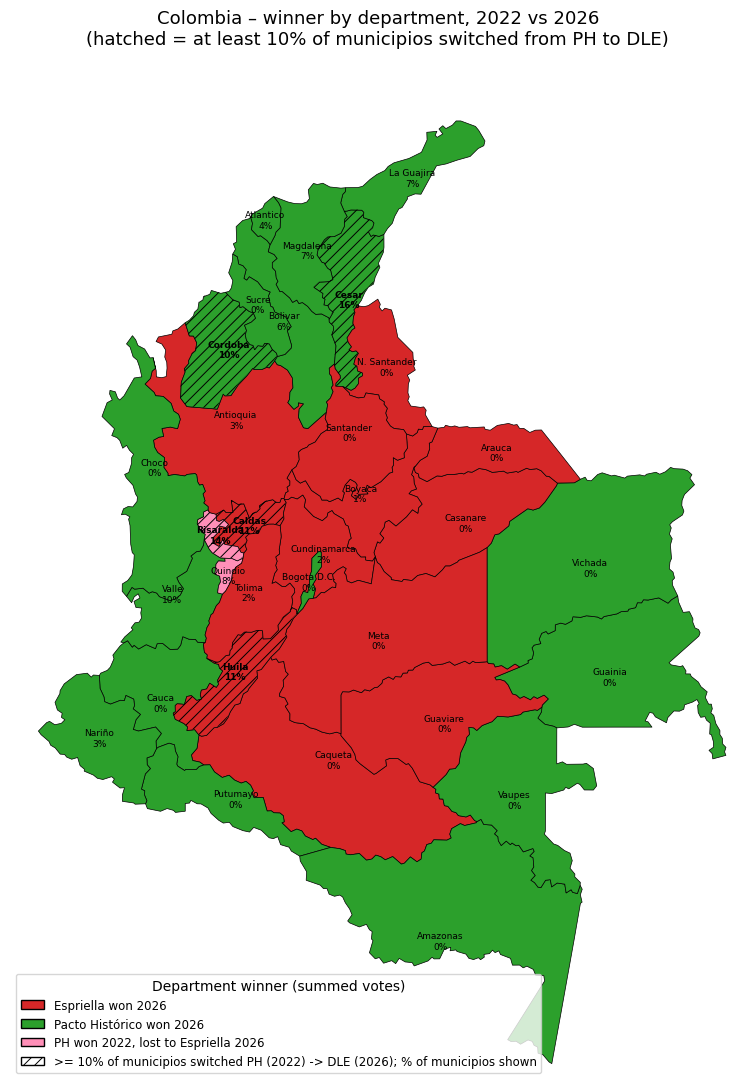

In [37]:
from matplotlib import rcParams
rcParams['hatch.linewidth'] = 0.7

SWITCH_MUNI_SHARE = 10      # hatch departments where at least this % of municipios switched from PH (2022) to DLE (2026)

res['switch_PH_to_DLE'] = (res['party_2022'] == 'Pacto Histórico') & (res['party_2026'] == 'De La Espriella')

swd = res.groupby('DES_DD').agg(n_municipios=('DES_MM', 'size'), n_switch=('switch_PH_to_DLE', 'sum'))
swd['switch_%'] = (100 * swd['n_switch'] / swd['n_municipios']).round(1)
swd['flagged'] = swd['switch_%'] >= SWITCH_MUNI_SHARE
swd['dane'] = swd.index.map(DANE)
print(f'{swd.flagged.sum()} of {len(swd)} departments have >= {SWITCH_MUNI_SHARE}% of municipios that switched from PH (2022) to DLE (2026)')
display(swd.sort_values('switch_%', ascending=False).reset_index().rename(columns={'DES_DD': 'Department'}))

flagged_codes = set(swd.loc[swd.flagged, 'dane'])
pct_by_code = dict(zip(swd['dane'], swd['switch_%']))

fig, ax = plt.subplots(figsize=(9, 11))
hatch_patches = []
for feat in sorted(geo['features'], key=lambda f: f['properties']['DPTO_CCDGO'] == '11'):   # Bogota on top
    code = feat['properties']['DPTO_CCDGO']
    if code not in mainland:
        continue
    patches = [MplPolygon(r, closed=True) for r in rings(feat['geometry'])]
    ax.add_collection(PatchCollection(patches, facecolor=color_by_code.get(code, '#ffffff'), edgecolor='black', linewidth=0.5))
    if code in flagged_codes:
        hatch_patches += [MplPolygon(r, closed=True) for r in rings(feat['geometry'])]
    xs = [x for r in rings(feat['geometry']) for x, y in r]; ys = [y for r in rings(feat['geometry']) for x, y in r]
    nm = name_by_code.get(code, '').title().replace('Norte De San', 'N. Santander')
    ax.text(np.mean([min(xs), max(xs)]), np.mean([min(ys), max(ys)]), f"{nm}\n{pct_by_code.get(code, 0):.0f}%",
            fontsize=6.5, ha='center', va='center', fontweight='bold' if code in flagged_codes else 'normal')
ax.add_collection(PatchCollection(hatch_patches, facecolor='none', edgecolor='black', linewidth=0, hatch='///'))

ax.set_xlim(-79.5, -66.5); ax.set_ylim(-4.5, 13.5)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('Colombia – winner by department, 2022 vs 2026\n(hatched = at least %g%% of municipios switched from PH to DLE)' % SWITCH_MUNI_SHARE,
             fontsize=13, pad=12)
handles = [Patch(facecolor=COLORS[k], edgecolor='black', label=k) for k in COLORS if k in set(dep['map_class'])]
handles.append(Patch(facecolor='white', edgecolor='black', hatch='///',
                     label=f'>= {SWITCH_MUNI_SHARE}% of municipios switched PH (2022) -> DLE (2026); % of municipios shown'))
ax.legend(handles=handles, loc='lower left', fontsize=8.5, frameon=True, title='Department winner (summed votes)')
plt.tight_layout()
plt.savefig('colombia_map_2022_2026_switch.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# Optional: export all tables to Excel
with pd.ExcelWriter('voting_analysis_results.xlsx') as xw:
    table_task1.to_excel(xw, sheet_name='Task1_categories', index=False)
    for t in THRESHOLDS:
        backlash[t].to_excel(xw, sheet_name=f'Task2_backlash_{t}pct', index=False)
    task3.to_excel(xw, sheet_name=f'Task3_espriella_{TASK3_THRESHOLD}pct', index=False)